In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/aptos2019-blindness-detection/sample_submission.csv
/kaggle/input/aptos2019-blindness-detection/train.csv
/kaggle/input/aptos2019-blindness-detection/test.csv
/kaggle/input/aptos2019-blindness-detection/train_images/ef476be214d4.png
/kaggle/input/aptos2019-blindness-detection/train_images/6dcde47060f9.png
/kaggle/input/aptos2019-blindness-detection/train_images/ec363f48867b.png
/kaggle/input/aptos2019-blindness-detection/train_images/17f6c7072f61.png
/kaggle/input/aptos2019-blindness-detection/train_images/b49b2fac2514.png
/kaggle/input/aptos2019-blindness-detection/train_images/af6166d57f13.png
/kaggle/input/aptos2019-blindness-detection/train_images/8d13c46e7d75.png
/kaggle/input/aptos2019-blindness-detection/train_images/c3b15bf9b4bc.png
/kaggle/input/aptos2019-blindness-detection/train_images/be68322c7223.png
/kaggle/input/aptos2019-blindness-detection/train_images/88e4399d207c.png
/kaggle/input/aptos2019-blindness-detection/train_images/0243404e8a00.png
/kaggle/input

# IMPORTING ESSENTIAL LIB

In [3]:
from tensorflow import lite
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import random, os
import shutil
import matplotlib.pyplot as plt
from matplotlib.image import imread
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import categorical_accuracy
from sklearn.model_selection import train_test_split

2025-04-19 13:44:20.693850: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1745070260.889382      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745070260.942756      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# READING THE DATA

In [4]:
df = pd.read_csv(r'/kaggle/input/aptos2019-blindness-detection/train.csv')
df.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


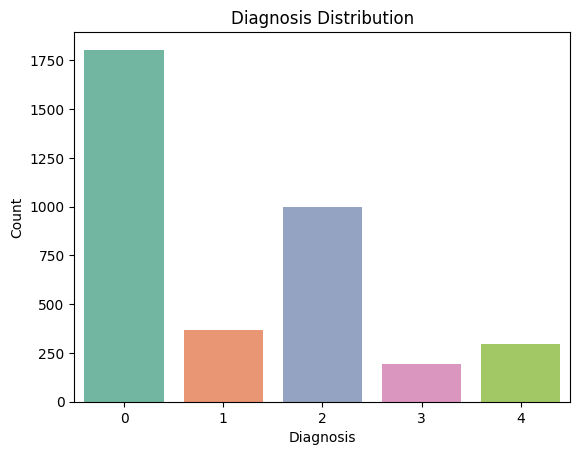

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Simple count plot of diagnosis values
sns.countplot(data=df, x='diagnosis', palette='Set2')
plt.title('Diagnosis Distribution')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()


In [6]:
import pandas as pd
from pathlib import Path

# Load the CSV
df = pd.read_csv('/kaggle/input/aptos2019-blindness-detection/train.csv')  

# Define the image folder
image_dir = Path('/kaggle/input/aptos2019-blindness-detection/train_images')  

# Add a 'filepaths' column to match each image to its full path
df['filepaths'] = df['id_code'].apply(lambda x: str(image_dir / f"{x}.png"))

# Check result
print(df.head(1))
print('Total images with labels:', len(df))
print(df['diagnosis'].value_counts())


        id_code  diagnosis                                          filepaths
0  000c1434d8d7          2  /kaggle/input/aptos2019-blindness-detection/tr...
Total images with labels: 3662
diagnosis
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64


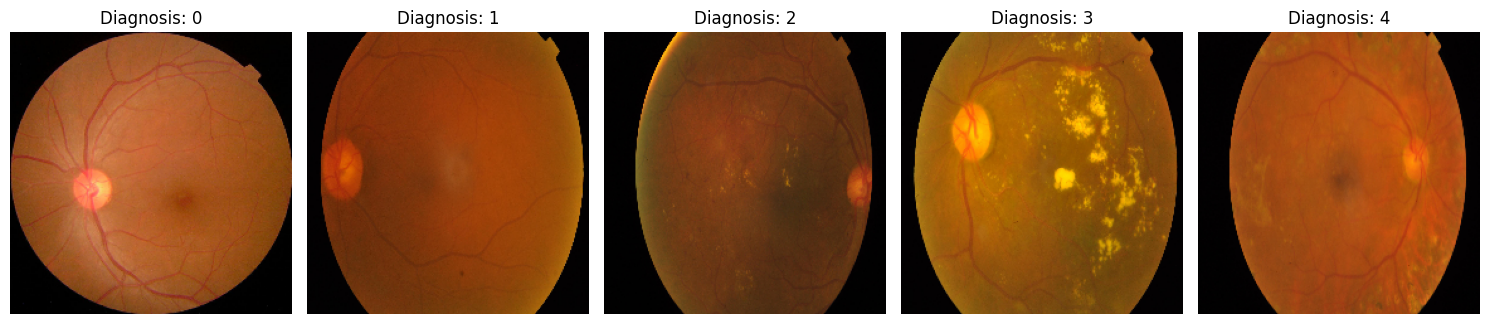

In [7]:
import matplotlib.pyplot as plt
import cv2

# Target image size (width, height)
IMG_SIZE = (224, 224)

# Unique diagnosis classes
classes = sorted(df['diagnosis'].unique())

# Set up the plot (1 row, len(classes) columns)
plt.figure(figsize=(15, 5))

for i, label in enumerate(classes):
    # Get one image path from this class
    sample_row = df[df['diagnosis'] == label].iloc[0]
    img_path = sample_row['filepaths']
    
    # Read image
    img = cv2.imread(img_path)
    
    # Resize and convert BGR to RGB
    img_resized = cv2.resize(img, IMG_SIZE)
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
    
    # Plot
    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img_rgb)
    plt.title(f'Diagnosis: {label}')
    plt.axis('off')

plt.tight_layout()
plt.show()


In [8]:
sample_list = []
max_size = 1500  # Set the maximum number of samples per class
groups = df.groupby('diagnosis')  # Group by diagnosis (your label column)

# Loop through each unique diagnosis label
for label in df['diagnosis'].unique():
    group = groups.get_group(label)  # Get the data for the current diagnosis class
    sample_count = len(group)  # Get the count of images in this class

    # If the class has more than max_size images, sample max_size randomly
    if sample_count > max_size:
        samples = group.sample(max_size, replace=False, random_state=123).reset_index(drop=True)
    # If the class has fewer images than max_size, sample the whole class
    else:
        samples = group.sample(frac=1.0, replace=False, random_state=123).reset_index(drop=True)

    sample_list.append(samples)  # Append the samples to the list

# Concatenate all sampled groups back together into a single DataFrame
df = pd.concat(sample_list, axis=0).reset_index(drop=True)

# Print the final number of samples and the label distribution
print(f'Total samples: {len(df)}')
print(df['diagnosis'].value_counts())


Total samples: 3357
diagnosis
0    1500
2     999
1     370
4     295
3     193
Name: count, dtype: int64


In [9]:
import os
import shutil

# Define the working directory and the directory for augmented images
working_dir = './'
aug_dir = os.path.join(working_dir, 'aug')

# Remove 'aug' directory if it exists and recreate it
if os.path.isdir(aug_dir):
    shutil.rmtree(aug_dir)
os.mkdir(aug_dir)

# Create subdirectories for each unique diagnosis label
for label in df['diagnosis'].unique():  # Using 'diagnosis' column instead of 'labels'
    dir_path = os.path.join(aug_dir, str(label))  # Ensure the label is treated as a string
    os.mkdir(dir_path)

# List the contents of the 'aug' directory to confirm
print(os.listdir(aug_dir))


['0', '3', '4', '2', '1']


# AGUMENTATION

In [11]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Set the target count for augmented images in each class
target = 1500  

# Define the ImageDataGenerator for augmentation
gen = ImageDataGenerator(
    horizontal_flip=True, 
    rotation_range=20, 
    width_shift_range=0.2,
    height_shift_range=0.2, 
    zoom_range=0.2
)

# Group the DataFrame by 'diagnosis' (the class labels)
groups = df.groupby('diagnosis')

# Loop over each unique class label (diagnosis)
for label in df['diagnosis'].unique():
    group = groups.get_group(label)  # Get all images in this class (label)
    sample_count = len(group)  # How many samples are in this class
    
    if sample_count < target:  # If the class has fewer than the target number of images
        aug_img_count = 0
        delta = target - sample_count  # Number of augmented images we need to generate
        
        # Define where to save the augmented images
        target_dir = os.path.join(aug_dir, str(label))
        
        # Create a generator for the augmentation process
        aug_gen = gen.flow_from_dataframe(
            group, 
            x_col='filepaths',  # Image file paths
            y_col=None,  # No labels needed for augmentation
            target_size=(224, 224),  # Resize images to 224x224
            class_mode=None,  # No classification needed for augmentation
            batch_size=32,  # Process 32 image at a time
            shuffle=False,  # Do not shuffle for proper sequential generation
            save_to_dir=target_dir,  # Directory to save augmented images
            save_prefix='aug-',  # Prefix for augmented image filenames
            save_format='png'  # Save in PNG format
        )
        
        # Generate augmented images until we've created the necessary amount
        while aug_img_count < delta:
            images = next(aug_gen)  # Get the next batch of augmented images
            aug_img_count += len(images)  # Update the count of augmented images generated

print(f"Augmentation complete for classes with less than {target} images.")
# Add logging to track progress
print(f"Generating augmented images for class: {label}")
print(f"Original count: {sample_count}, Target count: {target}, Generating {delta} images.")


Found 999 validated image filenames.
Found 295 validated image filenames.
Found 370 validated image filenames.
Found 193 validated image filenames.
Augmentation complete for classes with less than 1500 images.
Generating augmented images for class: 3
Original count: 193, Target count: 1500, Generating 1307 images.


In [12]:
import os

# Path to the augmented images directory
aug = './aug'

# List all subdirectories in the aug directory (representing different classes)
auglist = os.listdir(aug)

# Print the list of class directories
print(f"Classes found in 'aug' directory: {auglist}")

# Loop over each class in the 'aug' directory
for klass in auglist:
    classpath = os.path.join(aug, klass)  # Path to the current class folder
    if os.path.isdir(classpath):  # Ensure it's a directory
        flist = os.listdir(classpath)  # List of augmented images in the current class folder
        print(f'class: {klass}  file count: {len(flist)}')  # Print the class label and number of images


Classes found in 'aug' directory: ['0', '3', '4', '2', '1']
class: 0  file count: 0
class: 3  file count: 1318
class: 4  file count: 2424
class: 2  file count: 1024
class: 1  file count: 1398


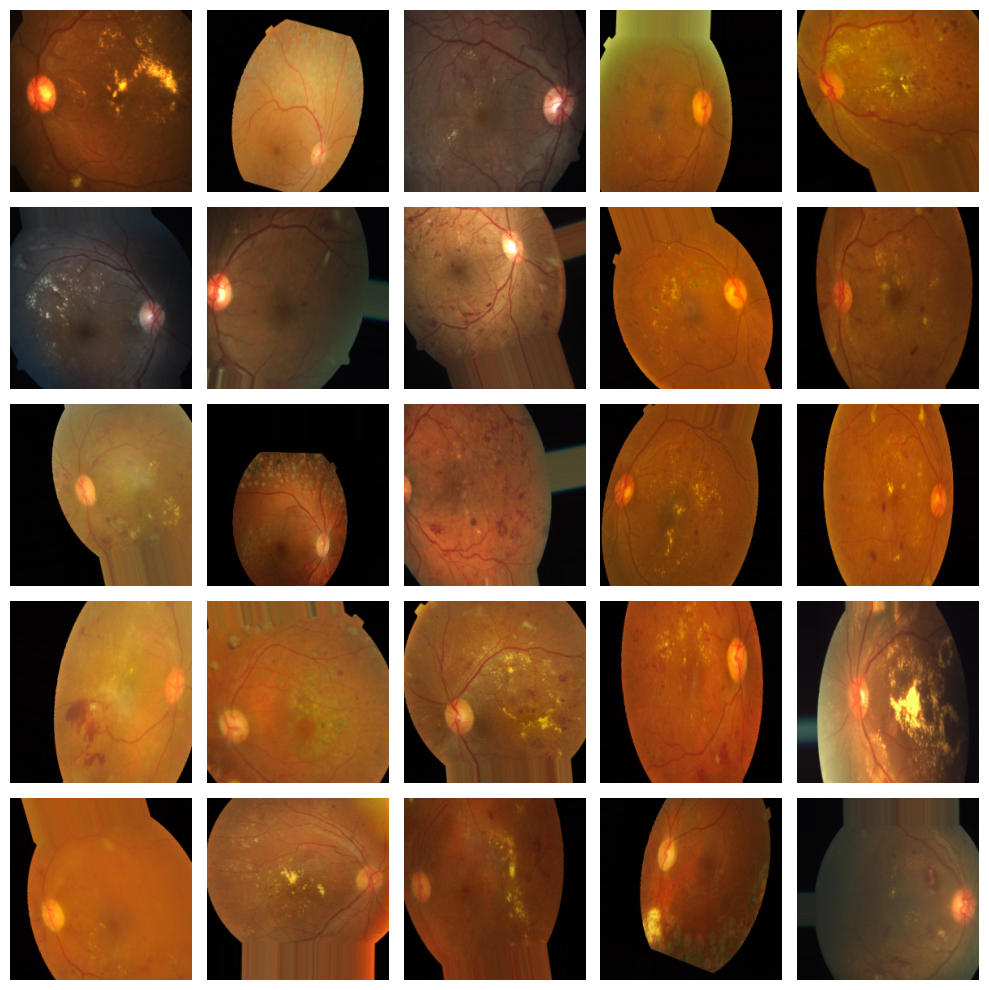

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))

# Reset the generator just in case
aug_gen.reset()

# Get one batch from the generator (batch_size should be ≥ 25)
batch = next(aug_gen)  # Shape: (batch_size, 224, 224, 3)

# Normalize and plot first 25 images
for i in range(25):
    image = batch[i] / 255.0  # Normalize for display
    plt.subplot(5, 5, i + 1)
    plt.imshow(image)
    plt.axis('off')

plt.tight_layout()
plt.show()


In [14]:
import pandas as pd
import os

aug_fpaths = []
aug_labels = []

# List all class folders inside the augmentation directory
classlist = os.listdir(aug_dir)

# Loop through each class folder and collect image paths and labels
for klass in classlist:
    classpath = os.path.join(aug_dir, klass)
    flist = os.listdir(classpath)
    
    for f in flist:
        fpath = os.path.join(classpath, f)
        aug_fpaths.append(fpath)
        aug_labels.append(int(klass))  # Convert to int to match 'diagnosis' dtype

# Create a DataFrame for the augmented data
Fseries = pd.Series(aug_fpaths, name='filepaths')
Lseries = pd.Series(aug_labels, name='diagnosis')  # Match your main df column
aug_df = pd.concat([Fseries, Lseries], axis=1)

# Combine original df and augmented df into a new dataframe
ndf = pd.concat([df, aug_df], axis=0).reset_index(drop=True)

# Print value counts to check class distribution
print("Original data distribution:\n", df['diagnosis'].value_counts(), "\n")
print("Augmented data distribution:\n", aug_df['diagnosis'].value_counts(), "\n")
print("Combined data distribution:\n", ndf['diagnosis'].value_counts())


Original data distribution:
 diagnosis
0    1500
2     999
1     370
4     295
3     193
Name: count, dtype: int64 

Augmented data distribution:
 diagnosis
4    2424
1    1398
3    1350
2    1024
Name: count, dtype: int64 

Combined data distribution:
 diagnosis
4    2719
2    2023
1    1768
3    1543
0    1500
Name: count, dtype: int64


In [ ]:
ndf.head()

# SPLITING THE DATA 

In [15]:
from sklearn.model_selection import train_test_split

# Define split ratios
train_split = 0.8
valid_split = 0.1
# Calculate the fraction of validation out of the remaining 20%
dummy_split = valid_split / (1 - train_split)

# Split into train and temp (valid + test)
train_df, dummy_df = train_test_split(
    ndf, 
    train_size=train_split, 
    shuffle=True, 
    random_state=123, 
    stratify=ndf['diagnosis']  # Optional: maintain class balance
)

# Split temp into valid and test
valid_df, test_df = train_test_split(
    dummy_df, 
    train_size=dummy_split, 
    shuffle=True, 
    random_state=123,
    stratify=dummy_df['diagnosis']  # Optional: maintain class balance
)

# Output dataset sizes
# Convert diagnosis column to strings for compatibility with categorical mode
train_df['diagnosis'] = train_df['diagnosis'].astype(str)
valid_df['diagnosis'] = valid_df['diagnosis'].astype(str)
test_df['diagnosis'] = test_df['diagnosis'].astype(str)
# Print the number of samples in each split
print(f"Train data size: {train_df.shape[0]}")
print(f"Validation data size: {valid_df.shape[0]}")
print(f"Test data size: {test_df.shape[0]}")


Train data size: 7642
Validation data size: 955
Test data size: 956


# GENRATORS

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd
import numpy as np

# Image configuration
height, width, channels = 224, 224, 3
img_size = (height, width)
img_shape = (height, width, channels)
batch_size = 40

# Calculate test batch size
length = len(test_df)
test_batch_size = max([i for i in range(1, 81) if length % i == 0])
test_steps = length // test_batch_size
print(f"Test batch size: {test_batch_size} | Test steps: {test_steps}")

# Custom image normalization function (to [-1, 1] scale)
def scalar(img):
    return img / 127.5 - 1

# ImageDataGenerators
train_datagen = ImageDataGenerator(
    preprocessing_function=scalar,
    horizontal_flip=True,
    rotation_range=30,  # Increased rotation range
    width_shift_range=0.2,  # Larger width shift
    height_shift_range=0.2,  # Larger height shift
    zoom_range=0.2,  # Stronger zooming
    shear_range=0.2,  # Add shear transformations
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=scalar)

# Create train generator
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepaths',
    y_col='diagnosis',
    target_size=img_size,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)


# Create validation generator
valid_gen = val_test_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col='filepaths',
    y_col='diagnosis',
    target_size=img_size,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=batch_size,
    shuffle=True
)

# Create test generator
test_gen = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepaths',
    y_col='diagnosis',
    target_size=img_size,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=test_batch_size,
    shuffle=False
)

# Class details
classes = list(train_gen.class_indices.keys())
class_count = len(classes)
train_steps = int(np.ceil(len(train_gen.labels) / batch_size))

print("Classes:", classes)
print("Train steps per epoch:", train_steps)


Test batch size: 4 | Test steps: 239
Found 7642 validated image filenames belonging to 5 classes.
Found 955 validated image filenames belonging to 5 classes.
Found 956 validated image filenames belonging to 5 classes.
Classes: ['0', '1', '2', '3', '4']
Train steps per epoch: 192


In [18]:
import matplotlib.pyplot as plt
import numpy as np

def show_image_samples(gen):
    class_indices = gen.class_indices
    classes = list(class_indices.keys())    

    images, labels = next(gen)  # Fetch one batch from the generator

    plt.figure(figsize=(20, 20))

    sample_count = min(len(labels), 25)  # Show max 25 images

    for i in range(sample_count):
        plt.subplot(5, 5, i + 1)
        image = (images[i] + 1) / 2  # unscale from [-1,1] to [0,1] if you used scalar()

        label_index = np.argmax(labels[i])
        class_name = classes[label_index]

        plt.imshow(image)
        plt.title(f"Label: {class_name}", color='green', fontsize=14)
        plt.axis('off')

    plt.tight_layout()
    plt.show()


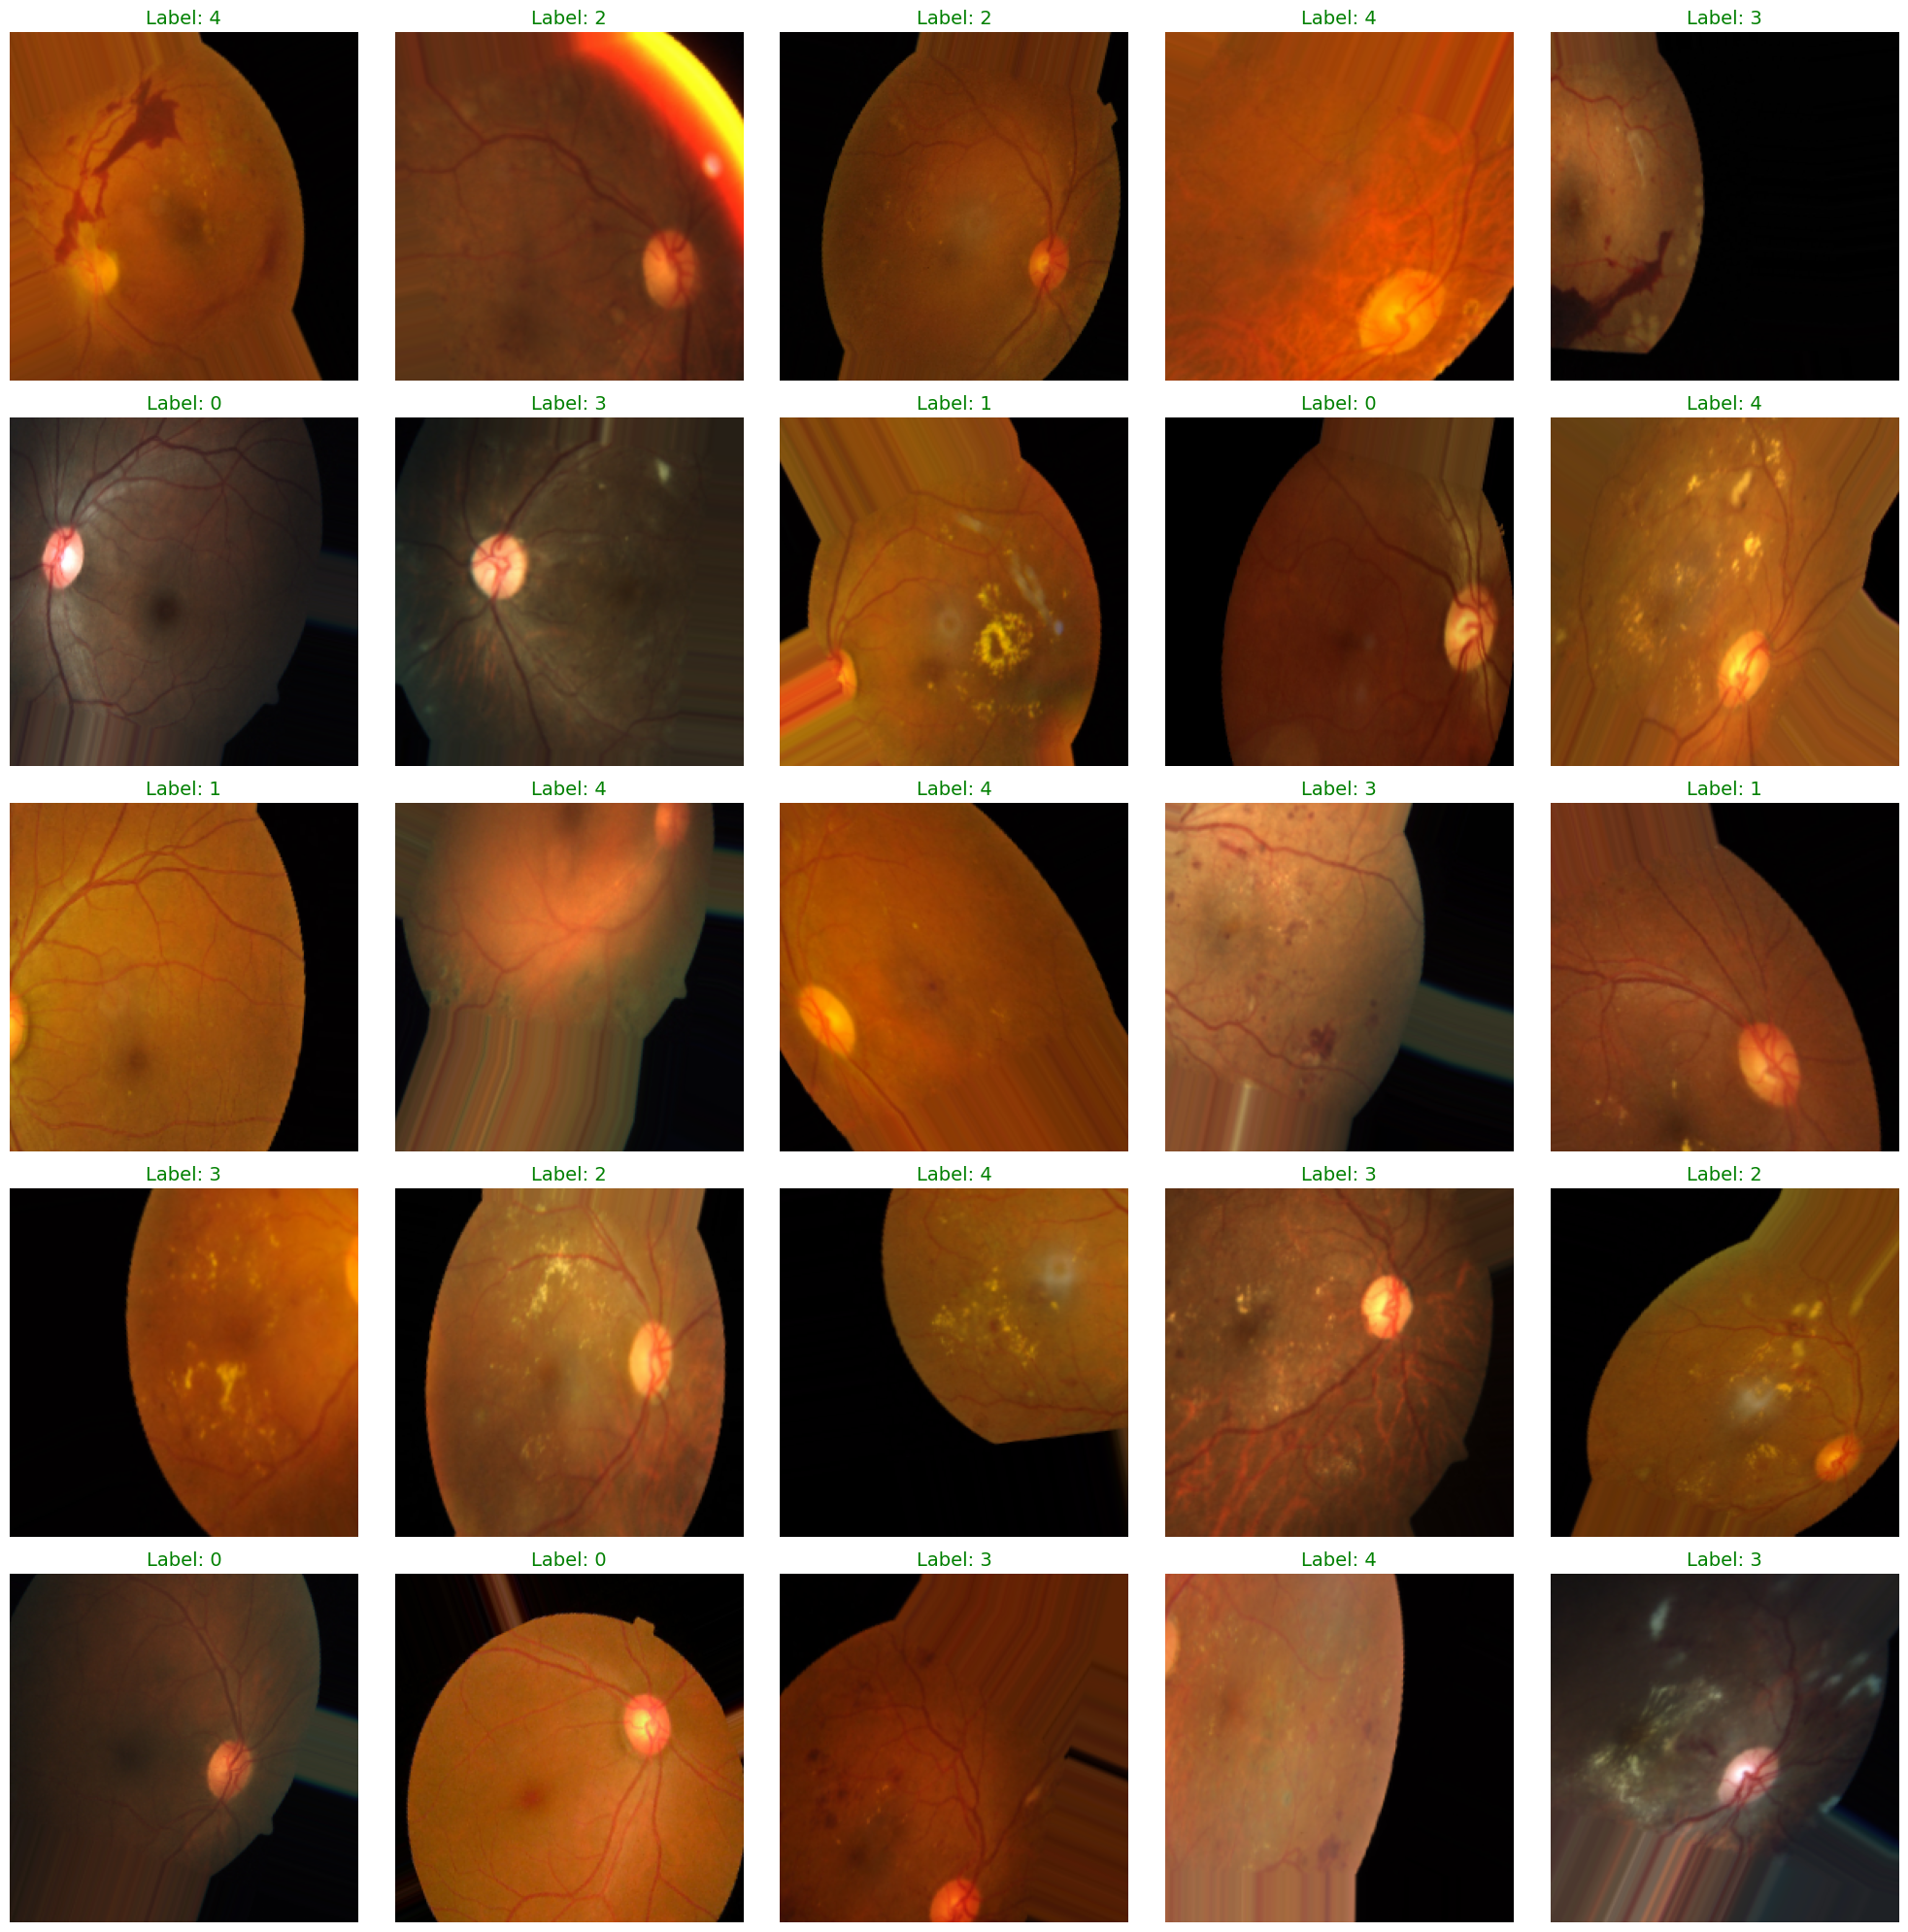

In [19]:
show_image_samples(train_gen)

# BUILD MODEL

In [20]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam


In [31]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam

# Input shape and class count
input_shape = (224, 224, 3)
num_classes = len(train_gen.class_indices)

# Load EfficientNetB0 with pretrained ImageNet weights
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)

# Unfreeze all layers of the base model
base_model.trainable = True

# Add custom classification layers
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Global average pooling layer
x = Dropout(0.3)(x)  # Dropout layer
output = Dense(num_classes, activation='softmax')(x)  # Output layer

# Create the final model
model = Model(inputs=base_model.input, outputs=output)

# Compile the model with a smaller learning rate for fine-tuning
model.compile(optimizer=Adam(learning_rate=0.0001), 
              loss='categorical_crossentropy', 
              metrics=['accuracy'])

# Print the model summary to confirm the structure
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_2 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ input_layer_1[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ normalization_1           │ (None, 224, 224, 3)    │              7 │ rescaling_2[0][0]      │
│ (Normalization)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ rescaling_3 (Rescaling)   │ (None, 224, 224, 3)    │              0 │ normalization_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv_pad             │ (None, 225, 225, 3)    │              0 │ rescaling_3[0][0]      │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_conv (Conv2D)        │ (None, 112, 112, 32)   │            864 │ stem_conv_pad[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_bn                   │ (None, 112, 112, 32)   │            128 │ stem_conv[0][0]        │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ stem_activation           │ (None, 112, 112, 32)   │              0 │ stem_bn[0][0]          │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_dwconv            │ (None, 112, 112, 32)   │            288 │ stem_activation[0][0]  │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_bn                │ (None, 112, 112, 32)   │            128 │ block1a_dwconv[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_activation        │ (None, 112, 112, 32)   │              0 │ block1a_bn[0][0]       │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_squeeze        │ (None, 32)             │              0 │ block1a_activation[0]… │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reshape        │ (None, 1, 1, 32)       │              0 │ block1a_se_squeeze[0]… │
│ (Reshape)                 │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block1a_se_reduce         │ (None, 1, 1, 8)        │            264 │ block1a_se_reshape[0]… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 4,013,953 (15.31 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [32]:
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

# ModelCheckpoint to save the best model
checkpoint = ModelCheckpoint("best_model.keras", monitor='val_loss', save_best_only=True, mode='min', verbose=1)

# Reduce learning rate if validation loss plateaus
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, verbose=1, min_lr=1e-6)

# Stop training if val_loss doesn't improve for several epochs
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# Combine callbacks into a list
callbacks = [checkpoint, reduce_lr, early_stop]


In [33]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    'balanced', 
    classes=np.unique(train_gen.labels), 
    y=train_gen.labels
)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}



In [41]:
# Train the model
model.fit(
    train_gen,
    epochs=15,
    verbose=1,
    callbacks=callbacks,
    validation_data=valid_gen
)


Epoch 1/15
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6008 - loss: 0.9931
Epoch 1: val_loss improved from inf to 1.79155, saving model to best_model.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 410s 2s/step - accuracy: 0.6010 - loss: 0.9927 - val_accuracy: 0.2031 - val_loss: 1.7916 - learning_rate: 1.0000e-04
Epoch 2/15
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7008 - loss: 0.7442
Epoch 2: val_loss did not improve from 1.79155
192/192 ━━━━━━━━━━━━━━━━━━━━ 370s 2s/step - accuracy: 0.7009 - loss: 0.7442 - val_accuracy: 0.2461 - val_loss: 2.0165 - learning_rate: 1.0000e-04
Epoch 3/15
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7621 - loss: 0.6163
Epoch 3: val_loss improved from 1.79155 to 1.47988, saving model to best_model.keras
192/192 ━━━━━━━━━━━━━━━━━━━━ 367s 2s/step - accuracy: 0.7621 - loss: 0.6162 - val_accuracy: 0.4094 - val_loss: 1.4799 - learning_rate: 1.0000e-04
Epoch 4/15
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7941 - loss: 0.5264
Epoch 4: 

In [42]:
# Save the final model
model.save('final_model.h5')
print("Final model saved.")


Final model saved.


Epoch 1/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9474 - loss: 0.1457
Epoch 1: val_loss did not improve from 0.24604
192/192 ━━━━━━━━━━━━━━━━━━━━ 371s 2s/step - accuracy: 0.9474 - loss: 0.1457 - val_accuracy: 0.9131 - val_loss: 0.2735 - learning_rate: 1.0000e-04
Epoch 2/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9522 - loss: 0.1339
Epoch 2: val_loss did not improve from 0.24604
192/192 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - accuracy: 0.9522 - loss: 0.1340 - val_accuracy: 0.9089 - val_loss: 0.2839 - learning_rate: 1.0000e-04
Epoch 3/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9591 - loss: 0.1112
Epoch 3: val_loss did not improve from 0.24604
192/192 ━━━━━━━━━━━━━━━━━━━━ 378s 2s/step - accuracy: 0.9591 - loss: 0.1112 - val_accuracy: 0.9068 - val_loss: 0.2856 - learning_rate: 1.0000e-04
Epoch 4/5
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9559 - loss: 0.1275
Epoch 4: val_loss did not improve from 0.24604

Epoch 4: ReduceLROnPlateau reducing l

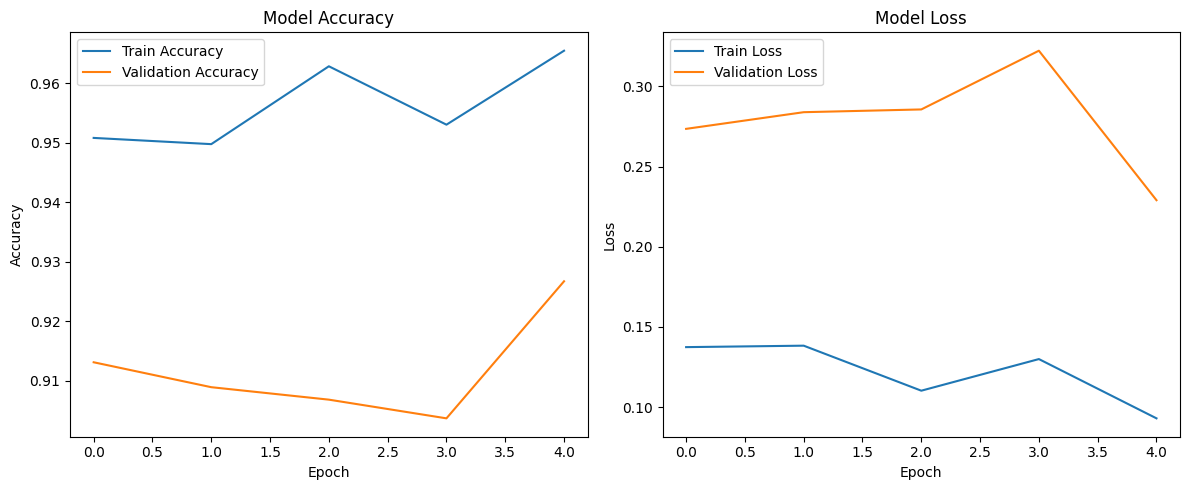

In [43]:
import matplotlib.pyplot as plt

# Assuming you've stored the history from model.fit()
history = model.fit(
    train_gen,
    epochs=5,
    verbose=1,
    callbacks=callbacks,
    validation_data=valid_gen
)

# Plotting accuracy and loss
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [45]:
test_loss, test_acc = model.evaluate(test_gen)
print(f"Test Accuracy: {test_acc*100:.2f}% | Test Loss: {test_loss:.4f}")


239/239 ━━━━━━━━━━━━━━━━━━━━ 37s 154ms/step - accuracy: 0.9496 - loss: 0.1363
Test Accuracy: 94.14% | Test Loss: 0.1492


In [52]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Get true labels and predicted labels
y_true = test_gen.classes
y_pred = model.predict(test_gen, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Get class labels
class_labels = list(test_gen.class_indices.keys())

# Classification report
report = classification_report(y_true, y_pred_classes, target_names=class_labels)
print(report)


239/239 ━━━━━━━━━━━━━━━━━━━━ 44s 153ms/step
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       150
           1       0.97      0.86      0.91       177
           2       0.87      0.96      0.91       203
           3       0.96      0.92      0.94       154
           4       0.97      0.96      0.97       272

    accuracy                           0.94       956
   macro avg       0.94      0.94      0.94       956
weighted avg       0.94      0.94      0.94       956



# **PRDECTION**

In [66]:
from collections import Counter
print(Counter(train_gen.labels))


Counter({4: 2175, 2: 1618, 1: 1414, 3: 1235, 0: 1200})


239/239 ━━━━━━━━━━━━━━━━━━━━ 37s 156ms/step


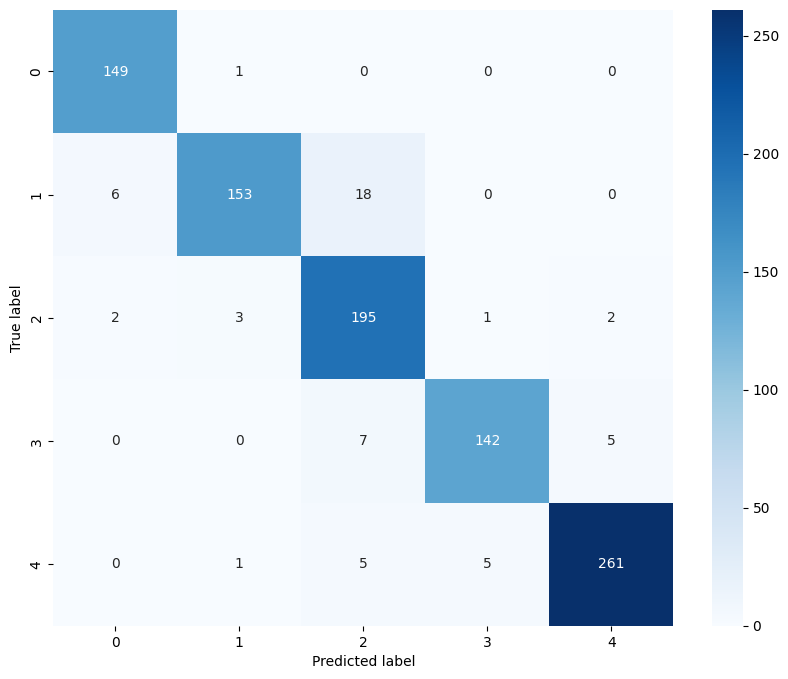

In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming you have ground truth labels and predictions for the test set
y_true = test_gen.labels
y_pred = model.predict(test_gen)
y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_gen.class_indices.keys(), yticklabels=train_gen.class_indices.keys())
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()
